# AI-Based Voltage Estimation Tutorial | <font color=red>Part 2</font>: MV Effects and Reference Voltage


## 1. Introduction

### What this tutorial does

This tutorial uses **simulated data only**. The goal is to understand what happens when the upstream medium-voltage (MV) condition changes while the customer P/Q demand profiles remain almost the same.

At each time step:

- **Input:** customer active and reactive power, and later selected reference voltages.
- **Output:** estimated voltage magnitudes for the LV customers.

The key question is whether P/Q alone is enough when the upstream MV network no longer stays fixed.

### What you will learn

You will learn how to:

1. compare fixed-upstream and varying-upstream voltage datasets;
2. explain why a P/Q-only voltage-estimation model fails under MV effects;
3. interpret the MV-effect decomposition into feeder-wide, phase and customer-specific terms;
4. evaluate reference voltage as an additional model input;
5. compare reference-meter number, placement and accuracy; and
6. understand why MV effects matter for hosting-capacity decisions.

### Notebook layout

- **Section 2:** complete tutorial workflow.
- **Section 3:** exercises that change parts of the workflow.
- **Section 4:** workspace for exercise code.

> **Important:** The test period is used for diagnosis and final comparison only. Do not use test results to tune a model or choose a reference-meter configuration unless that choice is explicitly part of the tutorial exercise.


## 2. Tutorial

### 2.1 Simulated LV Circuit with MV Effects

This tutorial uses the same simulated MG1 LV feeder as Part 1. It represents a typical three-phase unbalanced residential LV feeder, but it is not a real feeder and contains no real customer measurements.

- There are **31 simulated single-phase customer connections**.
- Every five minutes, the datasets contain P, Q and voltage values for all 31 customers.
- The Part 1 dataset keeps the upstream MV voltage fixed.
- The Part 2 dataset keeps the same customer P/Q demand, but allows the upstream MV condition to vary over time.
- A P/Q-only model cannot directly see the upstream voltage movement.
- Reference voltage measurements are tested as additional information.

The model is still not given line impedances or network equations directly. Instead, this tutorial asks whether the available measurements contain enough information for voltage estimation under a changing upstream condition.


<img style="float: middle;" src="network/MG1_topology.png" width="60%">


**<center>Figure 1. Simulated MG1 LV Feeder Topology</center>**

| Simulated customers | Time interval | Part 1 upstream condition | Part 2 upstream condition | Main question |
| :---: | :---: | :---: | :---: | :---: |
| 31 | 5 minutes | Fixed | Time-varying | Is P/Q enough, or is reference voltage needed? |


**<center>Table 1. Summary of the Simulated MV-Effect Experiment</center>**

### 2.2 Initialisation

#### 2.2.1 Import libraries

Run this cell first. It imports the packages used for data processing, plotting and result analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)

#### 2.2.2 Set the working folder

The working folder is where Jupyter is currently running.

In [2]:
WORKING_DIRECTORY = Path.cwd()
print(f"Working directory: {WORKING_DIRECTORY.resolve()}")

Working directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage


#### 2.2.3 Locate the Tutorial 2 resources

Tutorial 2 uses separate `data`, `results` and `network` folders. This cell locates those resources whether the notebook is opened from the repository root or from the Tutorial 2 folder.

In [3]:
TUTORIAL_FOLDER_NAME = "Tutorial_2_MV_Effects_Reference_Voltage"
folder_candidates = [
    WORKING_DIRECTORY,
    WORKING_DIRECTORY / TUTORIAL_FOLDER_NAME,
    WORKING_DIRECTORY.parent / TUTORIAL_FOLDER_NAME,
]

# Support running the notebook from either the repository root or its own folder.
TUTORIAL_DIRECTORY = next(
    (
        candidate
        for candidate in folder_candidates
        if (candidate / "data").is_dir()
        and (candidate / "results").is_dir()
        and (candidate / "network").is_dir()
    ),
    None,
)

if TUTORIAL_DIRECTORY is None:
    raise FileNotFoundError(
        "Could not find the Tutorial 2 data, results and network folders. "
        "Open this notebook from the repository root or from "
        f"{TUTORIAL_FOLDER_NAME}/."
    )

DATA_DIRECTORY = TUTORIAL_DIRECTORY / "data"
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results"

print(f"Tutorial folder: {TUTORIAL_DIRECTORY.resolve()}")

Tutorial folder: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage


### 2.3 Simulated LV and MV Datasets

#### 2.3.1 Load the training and test data

Part 2 uses two versions of the same simulated feeder:

- `synthetic_data_5_min_LV`: fixed upstream voltage; and
- `synthetic_data_5_min_MV`: time-varying upstream voltage.

Each version contains four files:

- `training/PQ.pkl`: training P and Q inputs;
- `training/V.pkl`: training voltage targets;
- `test/PQ.pkl`: held-out test P and Q inputs; and
- `test/V.pkl`: held-out test voltage targets.

The training files are used to inspect the MV effect and develop the comparison. The test files remain separate until the saved final model comparisons are reported.

In [4]:
LV_DATASET_NAME = "synthetic_data_5_min_LV"
MV_DATASET_NAME = "synthetic_data_5_min_MV"

DATA_FILES = {
    "PQ_lv_tr": DATA_DIRECTORY / LV_DATASET_NAME / "training" / "PQ.pkl",
    "V_lv_tr": DATA_DIRECTORY / LV_DATASET_NAME / "training" / "V.pkl",
    "PQ_lv_te": DATA_DIRECTORY / LV_DATASET_NAME / "test" / "PQ.pkl",
    "V_lv_te": DATA_DIRECTORY / LV_DATASET_NAME / "test" / "V.pkl",
    "PQ_mv_tr": DATA_DIRECTORY / MV_DATASET_NAME / "training" / "PQ.pkl",
    "V_mv_tr": DATA_DIRECTORY / MV_DATASET_NAME / "training" / "V.pkl",
    "PQ_mv_te": DATA_DIRECTORY / MV_DATASET_NAME / "test" / "PQ.pkl",
    "V_mv_te": DATA_DIRECTORY / MV_DATASET_NAME / "test" / "V.pkl",
}

missing_files = [path for path in DATA_FILES.values() if not path.is_file()]
if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "The Tutorial 2 datasets could not be found. Expected these files:\n"
        f"{missing_list}"
    )


def load_df_raw(path):
    """Load a pickle file without changing its original values or dtypes."""
    df = pd.read_pickle(path)
    return df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)


# Keep the raw DataFrames for inspection before numerical conversion.
PQ_lv_tr_df_raw = load_df_raw(DATA_FILES["PQ_lv_tr"])
V_lv_tr_df_raw = load_df_raw(DATA_FILES["V_lv_tr"])
PQ_lv_te_df_raw = load_df_raw(DATA_FILES["PQ_lv_te"])
V_lv_te_df_raw = load_df_raw(DATA_FILES["V_lv_te"])

PQ_mv_tr_df_raw = load_df_raw(DATA_FILES["PQ_mv_tr"])
V_mv_tr_df_raw = load_df_raw(DATA_FILES["V_mv_tr"])
PQ_mv_te_df_raw = load_df_raw(DATA_FILES["PQ_mv_te"])
V_mv_te_df_raw = load_df_raw(DATA_FILES["V_mv_te"])

print(f"Dataset directory: {DATA_DIRECTORY.resolve()}")
print("The eight dataset files were loaded successfully.")

Dataset directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage\data
The eight dataset files were loaded successfully.


#### 2.3.2 Check the data size

Each P/Q row contains 62 values in this order: `[P1, Q1, P2, Q2, ...]`. Each voltage row contains 31 values.

The expected sizes are:

- training period: 6,048 time steps;
- test period: 2,016 time steps;
- P/Q columns: 62; and
- voltage columns: 31.

The checks below stop the notebook if either dataset has the wrong shape or if the fixed- and varying-upstream versions do not align.


In [5]:
raw_datasets = {
    "PQ_lv_tr": (PQ_lv_tr_df_raw, "Fixed-upstream training inputs"),
    "V_lv_tr": (V_lv_tr_df_raw, "Fixed-upstream training targets"),
    "PQ_lv_te": (PQ_lv_te_df_raw, "Fixed-upstream test inputs"),
    "V_lv_te": (V_lv_te_df_raw, "Fixed-upstream test targets"),
    "PQ_mv_tr": (PQ_mv_tr_df_raw, "Varying-upstream training inputs"),
    "V_mv_tr": (V_mv_tr_df_raw, "Varying-upstream training targets"),
    "PQ_mv_te": (PQ_mv_te_df_raw, "Varying-upstream test inputs"),
    "V_mv_te": (V_mv_te_df_raw, "Varying-upstream test targets"),
}

dataset_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "first dtype": str(df.dtypes.iloc[0]),
            "meaning": meaning,
        }
        for name, (df, meaning) in raw_datasets.items()
    ]
)
display(dataset_summary)

expected_shapes = {
    "PQ_lv_tr": (6048, 62),
    "V_lv_tr": (6048, 31),
    "PQ_lv_te": (2016, 62),
    "V_lv_te": (2016, 31),
    "PQ_mv_tr": (6048, 62),
    "V_mv_tr": (6048, 31),
    "PQ_mv_te": (2016, 62),
    "V_mv_te": (2016, 31),
}

for name, expected_shape in expected_shapes.items():
    actual_shape = raw_datasets[name][0].shape
    if actual_shape != expected_shape:
        raise ValueError(
            f"{name} has shape {actual_shape}; expected {expected_shape}."
        )

print("\nPreview of the first four varying-upstream customer P/Q pairs:")
display(PQ_mv_tr_df_raw.iloc[:5, :8])

print("Fixed- and varying-upstream voltage previews:")
display(
    pd.concat(
        {
            "fixed upstream": V_lv_tr_df_raw.iloc[:5, :4],
            "varying upstream": V_mv_tr_df_raw.iloc[:5, :4],
        },
        axis=1,
    )
)

,dataset,rows,columns,first dtype,meaning
0,PQ_lv_tr,6048,62,object,Fixed-upstream training inputs
1,V_lv_tr,6048,31,object,Fixed-upstream training targets
2,PQ_lv_te,2016,62,object,Fixed-upstream test inputs
3,V_lv_te,2016,31,object,Fixed-upstream test targets
4,PQ_mv_tr,6048,62,object,Varying-upstream training inputs
5,V_mv_tr,6048,31,object,Varying-upstream training targets
6,PQ_mv_te,2016,62,object,Varying-upstream test inputs
7,V_mv_te,2016,31,object,Varying-upstream test targets



Preview of the first four varying-upstream customer P/Q pairs:


,0,1,2,3,4,5,6,7
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386,0.335303,0.051972
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703,0.59084,0.254372
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146,0.882382,-0.27772
3,0.107176,-0.01041,0.990251,-0.436451,0.25331,0.075004,0.230393,-0.026619
4,0.138526,0.01292,1.071487,-0.447064,0.237154,0.051309,0.640064,0.120067


Fixed- and varying-upstream voltage previews:


fixed upstream                                     varying upstream  \
               0           1           2           3                0   
0     249.821308  249.888347  249.892601  249.717129       248.504189   
1     249.899409  249.843989  249.866556  249.821587       248.520249   
2      249.93567  249.821681   249.89114  249.834439       248.571258   
3     249.896948  249.884214  249.874603  249.835795       248.561909   
4     249.798935  249.826984  249.938723  249.676499         248.4936   

                                       
            1           2           3  
0  248.551056  248.558164  248.399461  
1  248.405446  248.463877  248.442006  
2  248.412267  248.520852  248.469476  
3  248.498083  248.527219  248.500433  
4  248.454056  248.608261  248.370531

#### 2.3.3 Convert and check the data

As in Part 1, the code converts every DataFrame to numerical values and then creates `float32` NumPy arrays. It checks for missing or infinite values and separates the interleaved P/Q columns into individual P and Q arrays.

The final check compares the fixed- and varying-upstream P/Q inputs. If their relative difference is negligible, the two datasets form a controlled comparison: customer demand is effectively unchanged while the upstream voltage condition is different.


In [6]:
def to_numeric_df(df):
    """Convert every column to a numerical dtype.

    The pickle files are expected to contain numbers, but this conversion
    makes the check explicit for tutorial users.
    """
    return df.apply(pd.to_numeric, errors="coerce")


# Keep the pandas DataFrames for display, then create NumPy arrays for analysis.
PQ_lv_tr_df = to_numeric_df(PQ_lv_tr_df_raw)
V_lv_tr_df = to_numeric_df(V_lv_tr_df_raw)
PQ_lv_te_df = to_numeric_df(PQ_lv_te_df_raw)
V_lv_te_df = to_numeric_df(V_lv_te_df_raw)

PQ_mv_tr_df = to_numeric_df(PQ_mv_tr_df_raw)
V_mv_tr_df = to_numeric_df(V_mv_tr_df_raw)
PQ_mv_te_df = to_numeric_df(PQ_mv_te_df_raw)
V_mv_te_df = to_numeric_df(V_mv_te_df_raw)

PQ_lv_tr = PQ_lv_tr_df.to_numpy(np.float32)
V_lv_tr = V_lv_tr_df.to_numpy(np.float32)
PQ_lv_te = PQ_lv_te_df.to_numpy(np.float32)
V_lv_te = V_lv_te_df.to_numpy(np.float32)

PQ_mv_tr = PQ_mv_tr_df.to_numpy(np.float32)
V_mv_tr = V_mv_tr_df.to_numpy(np.float32)
PQ_mv_te = PQ_mv_te_df.to_numpy(np.float32)
V_mv_te = V_mv_te_df.to_numpy(np.float32)

datasets = {
    "PQ_lv_tr": PQ_lv_tr,
    "V_lv_tr": V_lv_tr,
    "PQ_lv_te": PQ_lv_te,
    "V_lv_te": V_lv_te,
    "PQ_mv_tr": PQ_mv_tr,
    "V_mv_tr": V_mv_tr,
    "PQ_mv_te": PQ_mv_te,
    "V_mv_te": V_mv_te,
}

# Stop before analysis if numerical conversion created invalid values.
invalid_summary = {
    name: int((~np.isfinite(matrix)).sum())
    for name, matrix in datasets.items()
}
print("Invalid-value summary:", invalid_summary)
if any(count > 0 for count in invalid_summary.values()):
    raise ValueError(
        "Missing or non-finite values were found after numerical conversion."
    )

# Recover P and Q from P|Q = [P1, Q1, P2, Q2, ...].
P_lv_tr, Q_lv_tr = PQ_lv_tr[:, 0::2], PQ_lv_tr[:, 1::2]
P_lv_te, Q_lv_te = PQ_lv_te[:, 0::2], PQ_lv_te[:, 1::2]
P_mv_tr, Q_mv_tr = PQ_mv_tr[:, 0::2], PQ_mv_tr[:, 1::2]
P_mv_te, Q_mv_te = PQ_mv_te[:, 0::2], PQ_mv_te[:, 1::2]

C = P_lv_tr.shape[1]
for P, Q, V in [
    (P_lv_tr, Q_lv_tr, V_lv_tr),
    (P_lv_te, Q_lv_te, V_lv_te),
    (P_mv_tr, Q_mv_tr, V_mv_tr),
    (P_mv_te, Q_mv_te, V_mv_te),
]:
    assert P.shape[1] == Q.shape[1] == V.shape[1] == C, (
        "|C| mismatch among P, Q and V."
    )

# Compare the two P/Q datasets relative to the largest absolute P/Q value.
max_train_pq_difference = float(np.max(np.abs(PQ_lv_tr - PQ_mv_tr)))
max_test_pq_difference = float(np.max(np.abs(PQ_lv_te - PQ_mv_te)))
max_pq_difference = max(max_train_pq_difference, max_test_pq_difference)
pq_scale = max(
    float(np.max(np.abs(PQ_lv_tr))),
    float(np.max(np.abs(PQ_lv_te))),
)
relative_pq_difference = max_pq_difference / pq_scale
PQ_RELATIVE_TOLERANCE = 1e-3  # 0.1% of the largest absolute P/Q value.

print(f"|C|={C}, |T_train|={P_mv_tr.shape[0]}, |T_test|={P_mv_te.shape[0]}")
print(
    "Shapes -> P_mv_tr", P_mv_tr.shape,
    "Q_mv_tr", Q_mv_tr.shape,
    "V_mv_tr", V_mv_tr.shape,
    "P|Q_mv_tr", PQ_mv_tr.shape,
)
print(
    "Maximum relative P/Q difference: "
    f"{relative_pq_difference:.6%}"
)

if relative_pq_difference <= PQ_RELATIVE_TOLERANCE:
    print(
        "The fixed- and varying-upstream P/Q profiles match within tolerance."
    )
else:
    print(
        "Warning: the P/Q profiles differ by more than the stated tolerance. "
        "Interpret the voltage comparison with care."
    )

Invalid-value summary: {'PQ_lv_tr': 0, 'V_lv_tr': 0, 'PQ_lv_te': 0, 'V_lv_te': 0, 'PQ_mv_tr': 0, 'V_mv_tr': 0, 'PQ_mv_te': 0, 'V_mv_te': 0}
|C|=31, |T_train|=6048, |T_test|=2016
Shapes -> P_mv_tr (6048, 31) Q_mv_tr (6048, 31) V_mv_tr (6048, 31) P|Q_mv_tr (6048, 62)
Maximum relative P/Q difference: 0.007412%
The fixed- and varying-upstream P/Q profiles match within tolerance.


#### 2.3.4 Visualise one day of P, Q and V

Before analysing the saved model results, it is useful to inspect the simulated time-series data. The training period contains **21 days** and the test period contains **7 days**. Each day has 288 five-minute instances.

Change `DATA_SPLIT_TO_PLOT`, `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT` in the next cell to explore different days and customers. Keep the training split selected during development; use the test split only for final inspection.

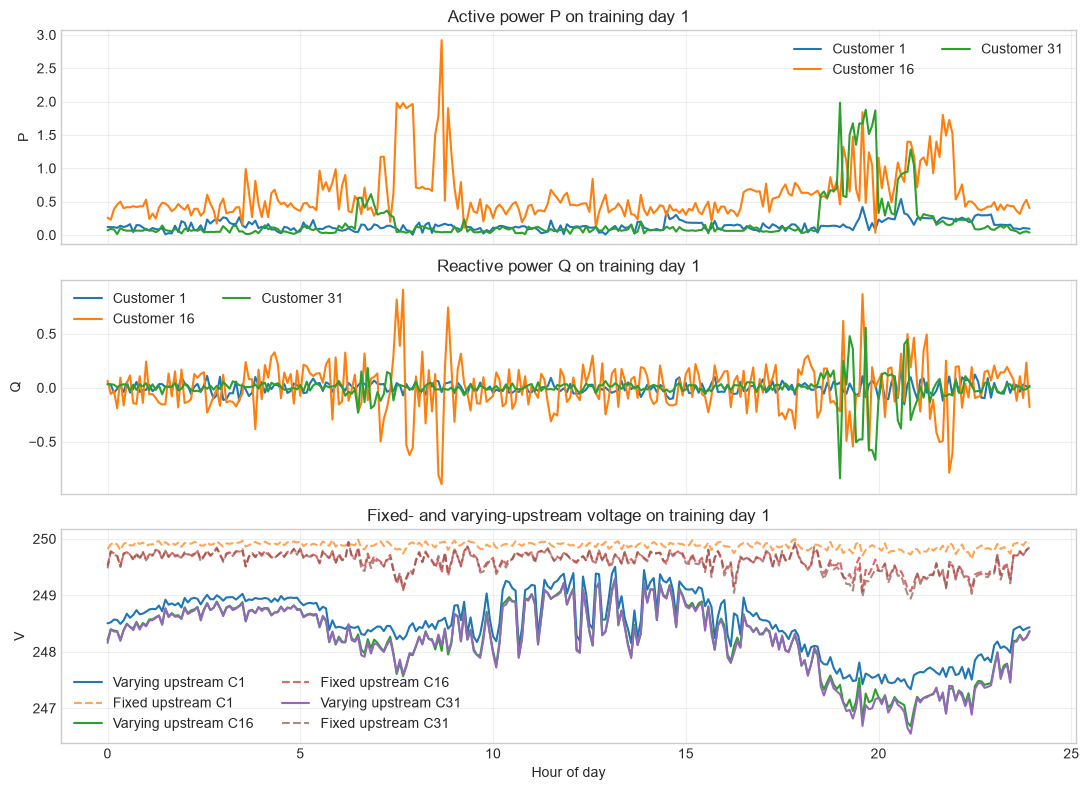

In [7]:
# Choose which part of the dataset to inspect.
# Use "training" for days 1-21, or "test" for days 1-7.
DATA_SPLIT_TO_PLOT = "training"
DAY_TO_PLOT = 1

# Plot a small number of customers so that the figure stays readable.
# Customer numbers are 1-based here because that is easier to read.
CUSTOMERS_TO_PLOT = [1, 16, 31]

# There are 12 five-minute samples per hour and 288 samples per day.
STEPS_PER_DAY = 24 * 60 // 5

plot_sources = {
    "training": {
        "P": P_mv_tr,
        "Q": Q_mv_tr,
        "V_fixed": V_lv_tr,
        "V_varying": V_mv_tr,
    },
    "test": {
        "P": P_mv_te,
        "Q": Q_mv_te,
        "V_fixed": V_lv_te,
        "V_varying": V_mv_te,
    },
}

split_name = DATA_SPLIT_TO_PLOT.lower()
if split_name not in plot_sources:
    raise ValueError("DATA_SPLIT_TO_PLOT must be 'training' or 'test'.")

selected_data = plot_sources[split_name]
available_days = selected_data["P"].shape[0] // STEPS_PER_DAY
if DAY_TO_PLOT < 1 or DAY_TO_PLOT > available_days:
    raise ValueError(
        f"DAY_TO_PLOT must be between 1 and {available_days} for {split_name}."
    )

customer_indices = [customer - 1 for customer in CUSTOMERS_TO_PLOT]
if min(customer_indices) < 0 or max(customer_indices) >= C:
    raise ValueError(
        f"CUSTOMERS_TO_PLOT must contain customer numbers from 1 to {C}."
    )

start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * 5 / 60

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
series_to_plot = [
    ("P", "Active power P"),
    ("Q", "Reactive power Q"),
]

for ax, (series_name, title) in zip(axes[:2], series_to_plot):
    matrix = selected_data[series_name]
    for customer_number, customer_index in zip(
        CUSTOMERS_TO_PLOT,
        customer_indices,
    ):
        ax.plot(
            hours,
            matrix[start:end, customer_index],
            label=f"Customer {customer_number}",
        )
    ax.set_ylabel(series_name)
    ax.set_title(f"{title} on {split_name} day {DAY_TO_PLOT}")

for customer_number, customer_index in zip(
    CUSTOMERS_TO_PLOT,
    customer_indices,
):
    axes[2].plot(
        hours,
        selected_data["V_varying"][start:end, customer_index],
        label=f"Varying upstream C{customer_number}",
    )
    axes[2].plot(
        hours,
        selected_data["V_fixed"][start:end, customer_index],
        linestyle="--",
        alpha=0.7,
        label=f"Fixed upstream C{customer_number}",
    )

axes[2].set_ylabel("V")
axes[2].set_title(
    f"Fixed- and varying-upstream voltage on {split_name} day {DAY_TO_PLOT}"
)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", ncol=2)

axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

### 2.4 Analyse the MV Effect

For matching P/Q operating points, define the MV effect as:

`MV effect = varying-upstream voltage - fixed-upstream voltage`

Because the customer P/Q profiles match within the stated tolerance, this difference isolates the voltage variation associated with the changing upstream condition. The calculation below uses the training period so that the held-out test period remains untouched during diagnosis.

,quantity,training MV effect [V]
0,mean,-1.3211
1,standard deviation,0.5478
2,minimum,-2.4770
3,maximum,0.0202


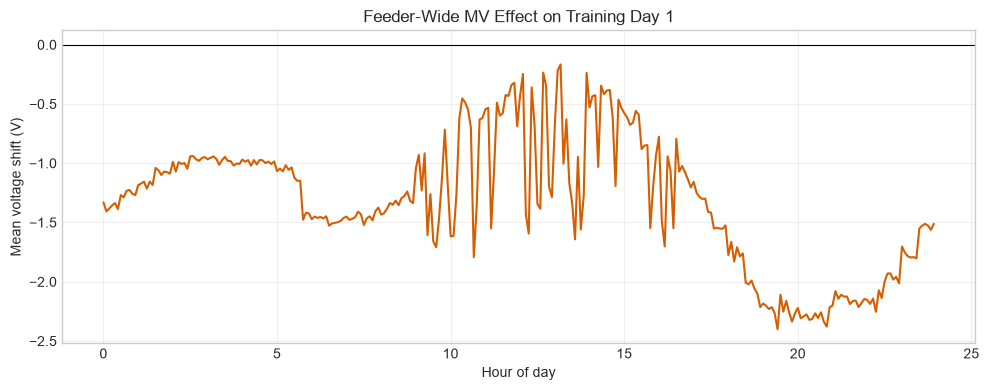

In [8]:
mv_effect_training = V_mv_tr - V_lv_tr
mv_effect_test = V_mv_te - V_lv_te  # Used only in the final exercises.

effect_summary = pd.DataFrame(
    {
        "quantity": ["mean", "standard deviation", "minimum", "maximum"],
        "training MV effect [V]": [
            mv_effect_training.mean(),
            mv_effect_training.std(),
            mv_effect_training.min(),
            mv_effect_training.max(),
        ],
    }
)
display(effect_summary.round(4))

# Plot the feeder-average effect for one training day.
DAY_TO_ANALYSE = 1
start = (DAY_TO_ANALYSE - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
feeder_mean_effect = mv_effect_training[start:end].mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(hours, feeder_mean_effect, color="#D55E00")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Hour of day")
plt.ylabel("Mean voltage shift (V)")
plt.title(f"Feeder-Wide MV Effect on Training Day {DAY_TO_ANALYSE}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The mean trace represents the voltage movement shared across the feeder during the selected training day. A clear time-varying shift, despite matching customer P/Q inputs, shows that P/Q alone does not uniquely determine the customer voltages in the varying-upstream case.

#### 2.4.1 Decompose the MV effect

The included decomposition separates the MV effect into three descriptive components:

- a feeder-wide time-varying component;
- a smaller phase-dependent component; and
- a customer-specific residual.

This is a diagnostic step, not a model input. It helps form the hypothesis that a small number of phase-aware voltage measurements could expose most of the missing upstream variation. Any final reference configuration must still be fixed before the held-out test comparison.

,component,variance share [%],std [V],interpretation
0,feeder-wide c(t),97.85145,0.542000,one measurement could capture this
1,per-phase p(t),2.14827,0.080308,needs one measurement per phase
2,per-customer r(t),0.00028,0.000917,would need a meter at every customer


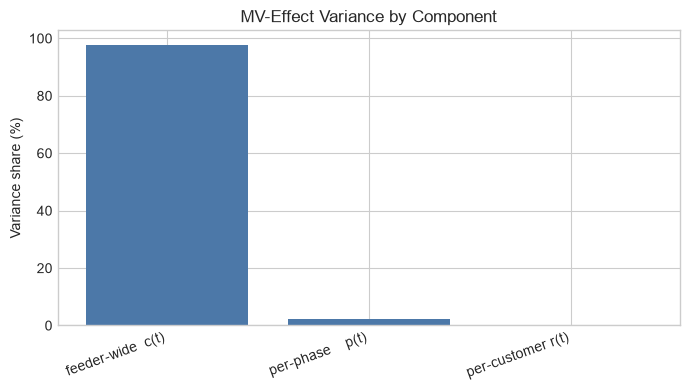

In [9]:
decomposition_file = (
    RESULTS_DIRECTORY
    / "01_diagnosing_mv_effects"
    / "mv_effect_decomposition.csv"
)
decomposition = pd.read_csv(decomposition_file)
display(decomposition)

plt.figure(figsize=(7, 4))
plt.bar(
    decomposition["component"],
    decomposition["variance share [%]"],
    color="#4C78A8",
)
plt.ylabel("Variance share (%)")
plt.title("MV-Effect Variance by Component")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

How to read the decomposition:

A dominant feeder-wide component indicates that the upstream movement affects many customers together. The smaller phase component explains why one reference per phase can be more informative than a single feeder-wide reference. The residual shows the variation not captured by those shared components.

### 2.5 Evaluate the P/Q-Only Baseline

Part 1 showed that P/Q-only models can estimate voltage accurately when the upstream condition is fixed. The included final-test results now compare that baseline with the varying-upstream case.

The important observation is not whether linear regression or a neural network is slightly better. Both model classes lose substantial accuracy when the upstream voltage changes but remains absent from the inputs. This is an **input-observability problem**, so increasing model complexity alone cannot recover the missing information.

,model,RMSE [V],Av. Dev. [V],Max. Dev. [V],R2
0,LV dataset | linear regression,0.0011,0.0008,0.0164,1.0000
1,LV dataset | neural network,0.0128,0.0078,0.2046,0.9984
2,MV dataset | linear regression,0.6185,0.4585,2.4627,0.1785
3,MV dataset | neural network,0.6126,0.4553,2.4821,0.1940


,model,RMSE [V],Av. Dev. [V],R2
0,"trained on LV, deployed on MV | linear",1.4305,1.3214,-3.3944
1,"trained on LV, deployed on MV | neural net",1.4335,1.3243,-3.4129
2,retrained on MV | linear,0.6185,0.4585,0.1785
3,retrained on MV | neural net,0.6126,0.4553,0.1940


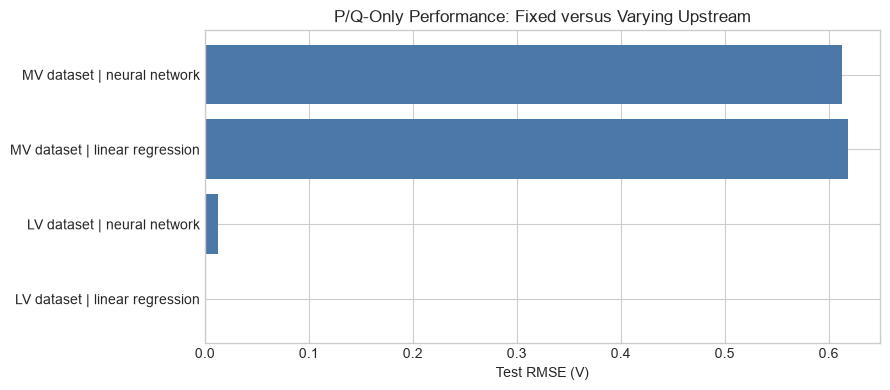

In [10]:
diagnosis_directory = RESULTS_DIRECTORY / "01_diagnosing_mv_effects"
model_comparison = pd.read_csv(
    diagnosis_directory / "lv_vs_mv_model_comparison.csv"
)
deployment_comparison = pd.read_csv(
    diagnosis_directory / "cross_dataset_deployment.csv"
)

comparison_columns = [
    "model",
    "RMSE [V]",
    "Av. Dev. [V]",
    "Max. Dev. [V]",
    "R2",
]
display(model_comparison[comparison_columns].round(4))
display(
    deployment_comparison[
        ["model", "RMSE [V]", "Av. Dev. [V]", "R2"]
    ].round(4)
)

plt.figure(figsize=(9, 4))
plt.barh(
    model_comparison["model"],
    model_comparison["RMSE [V]"],
    color="#4C78A8",
)
plt.xlabel("Test RMSE (V)")
plt.title("P/Q-Only Performance: Fixed versus Varying Upstream")
plt.tight_layout()
plt.show()

How to read the baseline results:

The P/Q-only models remain accurate in the fixed-upstream case but their errors rise sharply in the varying-upstream case. Similar degradation in linear and neural-network models is evidence that the missing upstream signal, rather than insufficient model complexity, is the main limitation.

### 2.6 Add Reference-Voltage Inputs

A reference voltage is a measured customer voltage supplied as an additional model input. It provides direct information about upstream movement that the P/Q-only baseline cannot observe.

The main three-reference configuration uses C1, C2 and C3, one customer from each phase. Their voltage measurements are appended to the 62 P/Q inputs. Because these three voltages are now model inputs, they must not also be counted as prediction targets in the reported accuracy. The reference-voltage model is therefore evaluated on C4-C31.

,model,RMSE [V],Av. Dev. [V],Max. Dev. [V],R2
0,A: P|Q only | linear regression,0.6183,0.4584,2.4627,0.1916
1,A: P|Q only | neural network,0.6613,0.4762,3.2260,0.0753
2,B: P|Q + Vref (input) | linear regression,0.0009,0.0006,0.0153,1.0000
3,B: P|Q + Vref (input) | neural network,0.0197,0.0134,0.2755,0.9992
4,C: predict relative to Vref | linear regression,0.0012,0.0008,0.0144,1.0000
5,C: predict relative to Vref | neural network,0.0111,0.0065,0.1691,0.9997


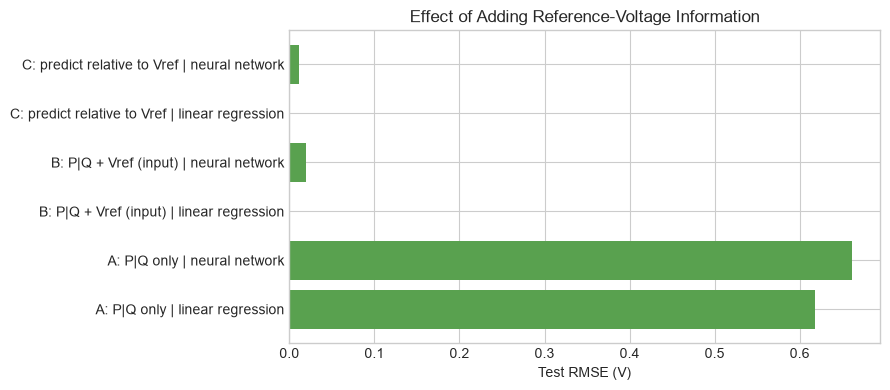

In [11]:
reference_directory = RESULTS_DIRECTORY / "02_reference_voltage"
reference_results = pd.read_csv(
    reference_directory / "three_strategies_results.csv"
)
display(reference_results[comparison_columns].round(4))

plt.figure(figsize=(9, 4))
plt.barh(
    reference_results["model"],
    reference_results["RMSE [V]"],
    color="#59A14F",
)
plt.xlabel("Test RMSE (V)")
plt.title("Effect of Adding Reference-Voltage Information")
plt.tight_layout()
plt.show()

How to read the reference-voltage results:

Both reference-based strategies are substantially more accurate than their P/Q-only counterparts. This supports the observability explanation: the improvement comes from adding information about the changing upstream condition, not simply from using a larger model.

Because reference inputs change the available prediction targets, treat this table as an initial strategy comparison. Section 2.7 provides the fair headline comparison on the fixed common scope C4-C31.

#### 2.6.1 Explore reference number, placement and accuracy

The included sensitivity studies explore three practical questions:

1. How does performance change as more phases receive a reference measurement?
2. How does the selected reference location affect the result?
3. How sensitive is the model to meter noise?

> **Comparison limitation:** configurations with different reference customers also have different non-reference evaluation sets. These plots are useful exploratory evidence, but they are not a fully controlled ranking. A definitive design study should compare every configuration on one fixed common customer set and select the configuration using training/validation data rather than the final test period.

,configuration,n references,reference customers,evaluated on,test RMSE [V],reduction vs none [%]
0,0 references,0,none,31,0.6185,0.00
1,1 reference (phase 1 only),1,C1,30,0.0823,86.70
2,"2 references (phases 1, 2)",2,"C1, C2",29,0.0124,97.99
3,3 references (one per phase),3,"C1, C2, C3",28,0.0009,99.85
4,6 references (two per phase),6,"C1, C2, C3, C4, C5, C6",25,0.0008,99.86
5,9 references (three per phase),9,"C1, C2, C3, C4, C5, C6, C7, C8, C9",22,0.0008,99.88


,position,reference customers,mean hops from transformer,test RMSE [V]
0,head,"C1, C2, C3",2.0,0.0009
1,mid,"C16, C17, C18",13.0,0.0005
2,end,"C26, C30, C31",18.7,0.0006


,meter accuracy [%],noise std [V],test RMSE [V],improvement vs P|Q only,RMSE / noise std
0,0.00,0.000,0.0009,657.8,inf
1,0.01,0.025,0.0216,28.7,0.86
2,0.05,0.125,0.0825,7.5,0.66
3,0.10,0.250,0.1479,4.2,0.59
4,0.20,0.500,0.2753,2.2,0.55
5,0.50,1.250,0.4848,1.3,0.39
6,1.00,2.500,0.5813,1.1,0.23


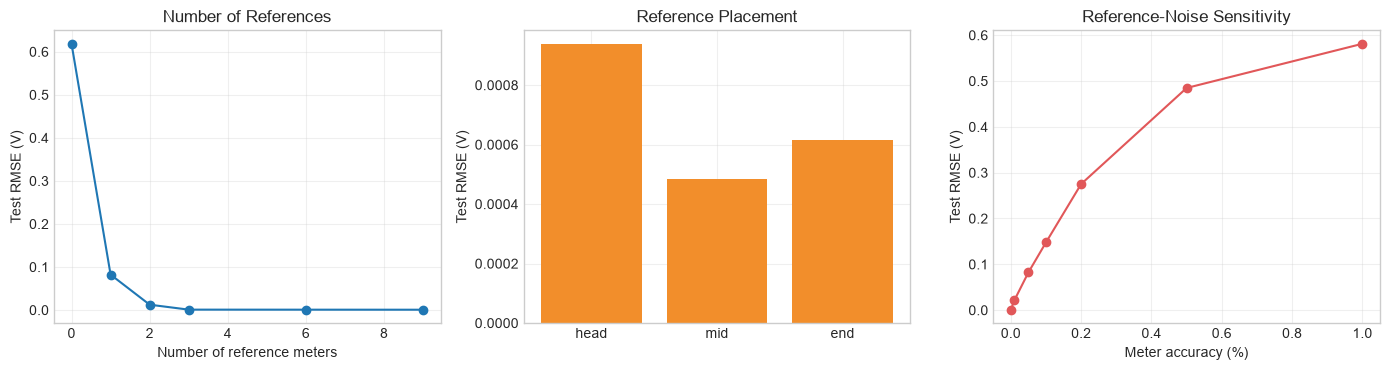

In [12]:
number_of_references = pd.read_csv(
    reference_directory / "number_of_references.csv"
)
reference_placement = pd.read_csv(
    reference_directory / "reference_placement.csv"
)
reference_noise = pd.read_csv(
    reference_directory / "reference_noise_sensitivity.csv"
)

display(number_of_references.round(4))
display(reference_placement.round(4))
display(reference_noise.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].plot(
    number_of_references["n references"],
    number_of_references["test RMSE [V]"],
    marker="o",
)
axes[0].set_xlabel("Number of reference meters")
axes[0].set_ylabel("Test RMSE (V)")
axes[0].set_title("Number of References")

axes[1].bar(
    reference_placement["position"],
    reference_placement["test RMSE [V]"],
    color="#F28E2B",
)
axes[1].set_ylabel("Test RMSE (V)")
axes[1].set_title("Reference Placement")

axes[2].plot(
    reference_noise["meter accuracy [%]"],
    reference_noise["test RMSE [V]"],
    marker="o",
    color="#E15759",
)
axes[2].set_xlabel("Meter accuracy (%)")
axes[2].set_ylabel("Test RMSE (V)")
axes[2].set_title("Reference-Noise Sensitivity")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

How to read the sensitivity results:

- One reference on only one phase leaves the other phase movements partly unobserved.
- One reference per phase captures substantially more of the upstream variation.
- Added meter noise reduces the benefit of Vref.

Treat the number and placement plots as exploratory because the evaluated customer set changes between configurations.

#### 2.6.2 Compare a clock proxy with a physical measurement

A time-of-day feature can appear useful when a simulated upstream profile repeats at the same time each day. However, the clock does not observe voltage. If the upstream pattern shifts, a clock-based proxy can fail while a reference meter continues to report the physical change.

The stress test below is therefore a robustness check: it separates a model that learns a repeated schedule from a model that receives the missing physical information directly.

,model,extra inputs,new hardware,test RMSE [V],fraction of the gap closed [%]
0,A: P|Q only (Notebook 1's failure),0,none,0.6183,0.00
1,D: + 2 clock harmonics + demand aggregates,10,none,0.4775,22.82
2,E: + a coefficient per 5-minute slot,288,none,0.0015,99.91
3,B: + 3 reference voltages,3,3 voltage monitors,0.0009,100.00


,model,"RMSE, upstream as trained [V]","RMSE, upstream shifted 2 h [V]",degradation
0,A: P|Q only,0.6183,0.6672,1.1
1,D: + clock harmonics,0.4775,0.5135,1.1
2,E: + 288-slot clock,0.0015,0.5579,368.9
3,B: + 3 reference voltages,0.0009,0.0017,1.8


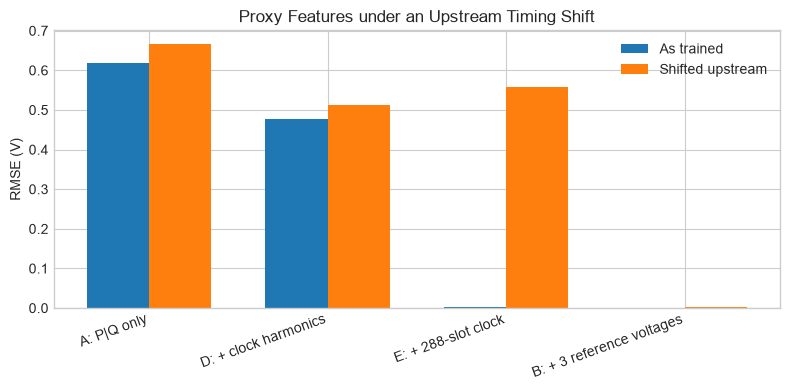

In [13]:
proxy_results = pd.read_csv(
    reference_directory / "proxy_vs_reference.csv"
)
proxy_stress_results = pd.read_csv(
    reference_directory / "proxy_stress_test_shifted_upstream.csv"
)

display(proxy_results.round(4))
display(proxy_stress_results.round(4))

x_positions = np.arange(len(proxy_stress_results))
bar_width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(
    x_positions - bar_width / 2,
    proxy_stress_results["RMSE, upstream as trained [V]"],
    bar_width,
    label="As trained",
)
plt.bar(
    x_positions + bar_width / 2,
    proxy_stress_results["RMSE, upstream shifted 2 h [V]"],
    bar_width,
    label="Shifted upstream",
)
plt.xticks(
    x_positions,
    proxy_stress_results["model"],
    rotation=20,
    ha="right",
)
plt.ylabel("RMSE (V)")
plt.title("Proxy Features under an Upstream Timing Shift")
plt.legend()
plt.tight_layout()
plt.show()

How to read the proxy stress test:

A proxy may perform well while the upstream timing matches the training pattern. Its error rises when that timing is shifted because the feature does not observe the actual voltage. A measured reference voltage remains tied to the physical condition and is therefore the more defensible input.

### 2.7 Compare the Models on a Common Scope

A fair comparison must use the same held-out test period, metrics and prediction targets. The file `overall_metrics_common_customers.csv` therefore evaluates all three models on the same 28 non-reference customers, C4-C31:

- fixed-upstream P/Q-only baseline;
- varying-upstream P/Q-only baseline; and
- varying-upstream P/Q + Vref model.

The analysis keeps only the evidence needed for the main conclusion:

1. the common-scope overall metrics;
2. RMSE by phase and feeder section, to check whether the result is consistent across the network;
3. the relationship between MV-effect variability and P/Q-only error; and
4. a short summary of the improvement obtained from Vref.

Phase and topology labels are used only for interpretation; they are **not** neural-network inputs. The correlation is descriptive and does not by itself establish causation.

,model,RMSE [V],Av. Dev. [V],Max. Dev. [V],R2
0,LV P/Q-only,0.0132,0.0081,0.2046,0.9983
1,MV P/Q-only,0.6147,0.4569,2.4821,0.2011
2,MV + Vref,0.0197,0.0134,0.2755,0.9992


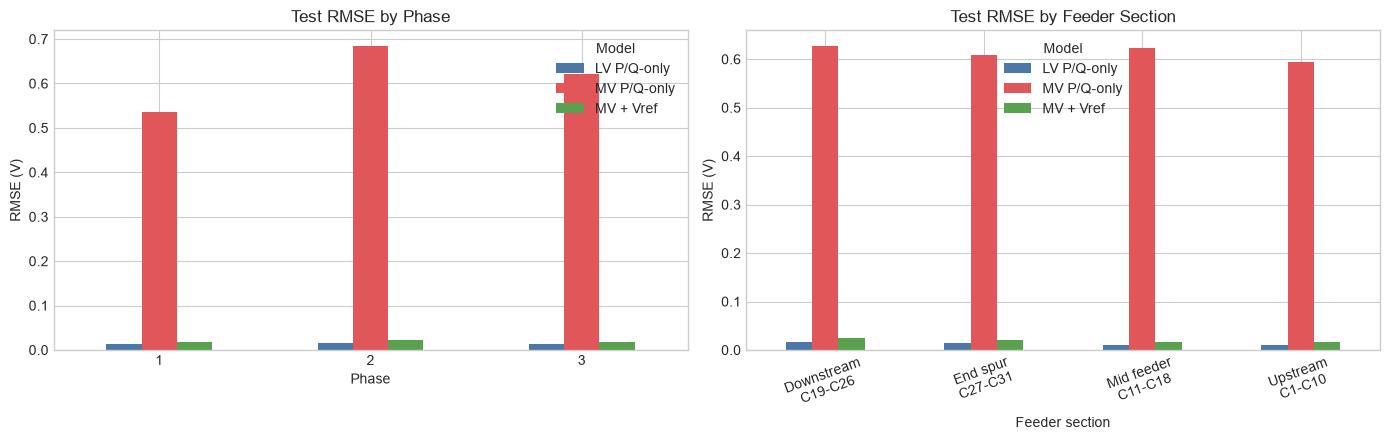

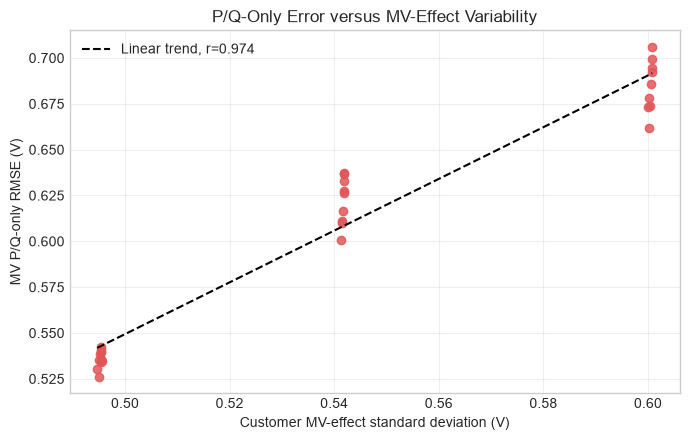

,quantity,value
0,RMSE reduction after adding Vref,96.8%
1,MV-to-LV RMSE gap closed by Vref,98.9%
2,Customers improved after adding Vref,28/28


In [14]:
case_study_directory = RESULTS_DIRECTORY / "03_case_studies"
overall_common = pd.read_csv(
    case_study_directory / "overall_metrics_common_customers.csv"
)
phase_metrics = pd.read_csv(
    case_study_directory / "per_phase_metrics.csv"
)
section_metrics = pd.read_csv(
    case_study_directory / "per_section_metrics.csv"
)
customer_metrics = pd.read_csv(
    case_study_directory / "per_customer_metrics.csv"
)
error_drivers = pd.read_csv(
    case_study_directory / "per_customer_error_drivers.csv"
)

model_order = ["LV P/Q-only", "MV P/Q-only", "MV + Vref"]
model_colors = ["#4C78A8", "#E15759", "#59A14F"]

display(overall_common[comparison_columns].round(4))

phase_rmse = phase_metrics.pivot(
    index="phase",
    columns="model",
    values="rmse",
)[model_order]
section_rmse = section_metrics.pivot(
    index="section",
    columns="model",
    values="rmse",
)[model_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
phase_rmse.plot(kind="bar", ax=axes[0], color=model_colors)
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("RMSE (V)")
axes[0].set_title("Test RMSE by Phase")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Model")

section_rmse.plot(kind="bar", ax=axes[1], color=model_colors)
axes[1].set_xlabel("Feeder section")
axes[1].set_ylabel("RMSE (V)")
axes[1].set_title("Test RMSE by Feeder Section")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Model")
fig.tight_layout()
plt.show()

mv_effect_variability = error_drivers["MV effect std [V]"]
mv_pq_customer_rmse = error_drivers["MV P/Q-only"]
mv_effect_correlation = float(
    np.corrcoef(mv_effect_variability, mv_pq_customer_rmse)[0, 1]
)
trend = np.polyfit(mv_effect_variability, mv_pq_customer_rmse, deg=1)
trend_x = np.linspace(
    mv_effect_variability.min(),
    mv_effect_variability.max(),
    100,
)

plt.figure(figsize=(7, 4.5))
plt.scatter(
    mv_effect_variability,
    mv_pq_customer_rmse,
    color="#E15759",
    alpha=0.85,
)
plt.plot(
    trend_x,
    np.polyval(trend, trend_x),
    "--",
    color="black",
    label=f"Linear trend, r={mv_effect_correlation:.3f}",
)
plt.xlabel("Customer MV-effect standard deviation (V)")
plt.ylabel("MV P/Q-only RMSE (V)")
plt.title("P/Q-Only Error versus MV-Effect Variability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

overall_rmse = overall_common.set_index("model")["RMSE [V]"]
lv_pq_rmse = float(overall_rmse["LV P/Q-only"])
mv_pq_rmse = float(overall_rmse["MV P/Q-only"])
mv_vref_rmse = float(overall_rmse["MV + Vref"])

vref_rmse_reduction = 100 * (mv_pq_rmse - mv_vref_rmse) / mv_pq_rmse
mv_lv_gap_closed = 100 * (
    (mv_pq_rmse - mv_vref_rmse) / (mv_pq_rmse - lv_pq_rmse)
)
customers_improved = int(
    (customer_metrics["MV + Vref"] < customer_metrics["MV P/Q-only"]).sum()
)

vref_benefit = pd.DataFrame(
    {
        "quantity": [
            "RMSE reduction after adding Vref",
            "MV-to-LV RMSE gap closed by Vref",
            "Customers improved after adding Vref",
        ],
        "value": [
            f"{vref_rmse_reduction:.1f}%",
            f"{mv_lv_gap_closed:.1f}%",
            f"{customers_improved}/{len(customer_metrics)}",
        ],
    }
)
display(vref_benefit)

The common-scope evidence supports three conclusions:

- varying upstream conditions increase P/Q-only error across all phases and feeder sections;
- customers with more variable MV effects tend to have larger P/Q-only error; and
- Vref reduces RMSE for all 28 evaluated customers and closes most of the MV-to-LV error gap.

The overall table and Vref summary provide the main result. The two figures only check that this conclusion is consistent across the network and associated with the missing MV effect.

### 2.8 Optional Extension: MV-Aware Hosting Capacity

The core voltage-estimation comparison is complete. This optional extension shows why the missing MV input matters in a downstream application.

Hosting capacity depends on available voltage headroom. When the upstream voltage changes, that headroom also changes with time. A model that misses the MV effect can therefore produce a precise-looking but biased hosting-capacity estimate. The four saved studies compare the fixed-upstream assumption, measured-MV ground truth, the P/Q-only model and the Vref model.

,study,hosting capacity [kW/customer],total feeder PV [kW],limiting customer,error vs ground truth [%]
0,A. LV assumption,4.118,115.3,C25,-14.9
1,B. Ground truth (measured MV),4.841,135.5,C31,0.0
2,C. P/Q-only model,5.693,159.4,C31,17.6
3,D. Vref model,4.866,136.2,C25,0.5


,day,Ground truth (MV),LV assumption,P|Q-only model,Vref model
0,1,5.002,4.360,5.825,5.050
1,2,4.841,4.197,6.031,4.887
2,3,5.190,4.527,7.371,5.242
3,4,4.850,4.120,5.811,4.866
4,5,5.249,4.644,6.299,5.258
5,6,4.884,4.118,5.693,4.938
6,7,5.152,4.803,6.568,5.185


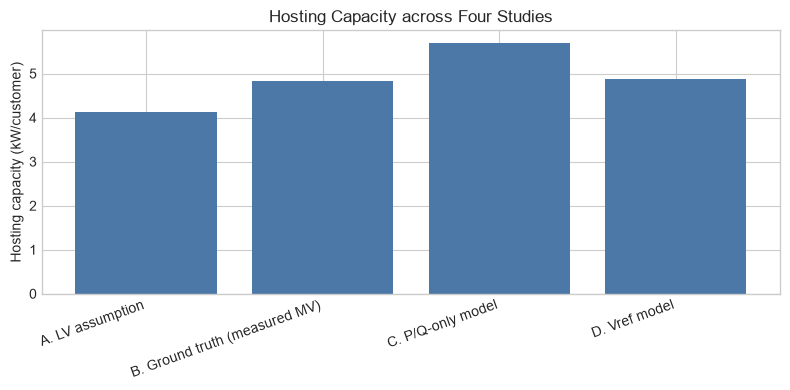

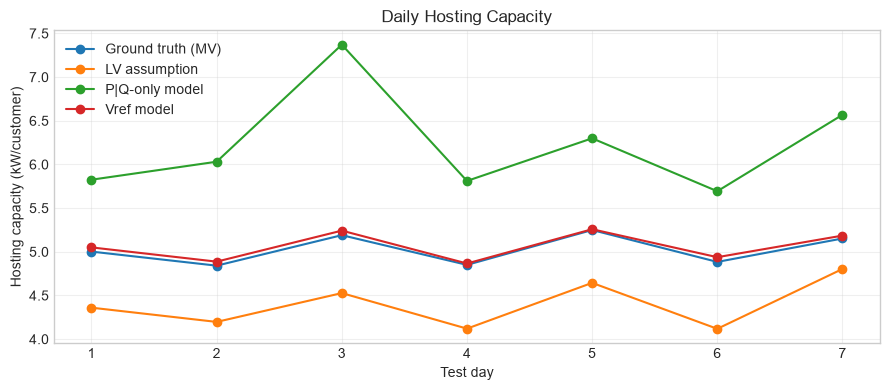

In [15]:
hosting_capacity_directory = (
    RESULTS_DIRECTORY / "04_mv_aware_hosting_capacity"
)
hosting_capacity_results = pd.read_csv(
    hosting_capacity_directory / "hosting_capacity_four_studies.csv"
)
daily_hosting_capacity = pd.read_csv(
    hosting_capacity_directory / "daily_hosting_capacity.csv"
)

display(hosting_capacity_results.round(3))
display(daily_hosting_capacity.round(3))

plt.figure(figsize=(8, 4))
plt.bar(
    hosting_capacity_results["study"],
    hosting_capacity_results["hosting capacity [kW/customer]"],
    color="#4C78A8",
)
plt.ylabel("Hosting capacity (kW/customer)")
plt.title("Hosting Capacity across Four Studies")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
for column in daily_hosting_capacity.columns:
    if column != "day":
        plt.plot(
            daily_hosting_capacity["day"],
            daily_hosting_capacity[column],
            marker="o",
            label=column,
        )

plt.xlabel("Test day")
plt.ylabel("Hosting capacity (kW/customer)")
plt.title("Daily Hosting Capacity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

How to read the hosting-capacity results:

- The measured-MV study is the ground-truth reference.
- The P/Q-only model overestimates hosting capacity because it does not observe the upstream voltage movement.
- The Vref model is much closer to ground truth, showing that improved voltage observability also improves the downstream decision.

This extension demonstrates impact for this simulated case; it is not a general hosting-capacity guarantee.

### 2.9 Interpret the Results and Limitations

The Part 2 workflow leads to five practical conclusions:

1. P/Q-only voltage estimation can work accurately when the upstream condition is fixed.
2. When upstream MV voltage varies, P/Q-only models miss a major voltage driver.
3. Increasing model complexity does not solve this input-observability problem.
4. One measured reference voltage per phase makes most of the missing upstream variation visible.
5. A fair comparison must use the same test period, metrics and non-reference customers.

The results also have clear limits. They come from one simulated feeder and one supplied upstream pattern. The sensitivity studies do not always use an identical customer scope, and clock features may exploit repeated timing rather than measure the physical cause. A deployment study would need to validate reference selection, meter quality and robustness on representative training/validation periods before one final test.

The broader lesson is that a power-system ML model can explain only the variation visible in its inputs.

## 3. Exercises

Read all three exercises before starting. Put your exercise code in **Section 4: Simulation Workspace**.

These exercises analyse the included final results; they do not tune or retrain a model on the held-out test period.

### Exercise: Investigate MV Effects and Reference Voltage

**E.1 - Inspect the MV effect for one customer**

- Choose one customer and one test day.
- Plot `V_MV - V_LV` for that customer.
- Report the mean and standard deviation of the effect.
- State whether the effect appears mainly feeder-wide or customer-specific.

**E.2 - Interpret the reference-meter sensitivity table**

- Use `number_of_references.csv`.
- Find the smallest included configuration with test RMSE below `0.05 V`.
- Report which reference customers are used and how many customers are evaluated.
- Explain why rows with different evaluation scopes are not a fully fair model-selection comparison.

**E.3 - Compare hosting-capacity error**

- Use `hosting_capacity_four_studies.csv`.
- Identify which study overestimates hosting capacity the most.
- Identify which study is closest to ground truth, excluding ground truth itself.
- Explain what this comparison suggests about the value of a measured reference voltage.


## 4. Simulation Workspace

Write and run your exercise code below.

In [16]:
# Assemble and run the code required for Exercises E.1-E.3 here.
